   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
Dataset Shape: (5169, 3)
label
ham     4516
spam     653
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



DISTILBERT MODEL PERFORMANCE
eval_loss : 0.027932453900575638
eval_accuracy : 0.9912959381044487
eval_precision : 0.9841269841269841
eval_recall : 0.9465648854961832
eval_f1 : 0.9649805447470817
eval_runtime : 219.5401
eval_samples_per_second : 4.71
eval_steps_per_second : 0.592
epoch : 3.0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Classification Report:

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       903
        spam       0.98      0.95      0.96       131

    accuracy                           0.99      1034
   macro avg       0.99      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



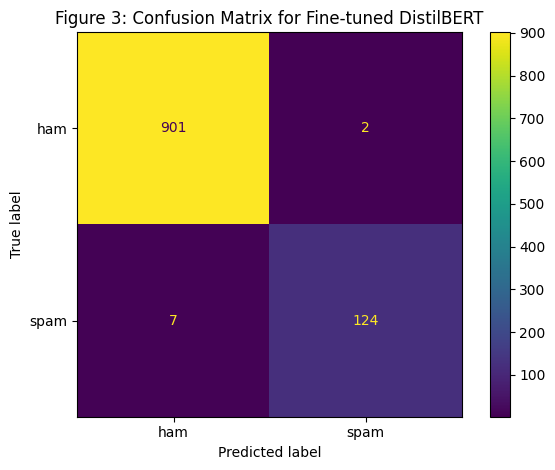

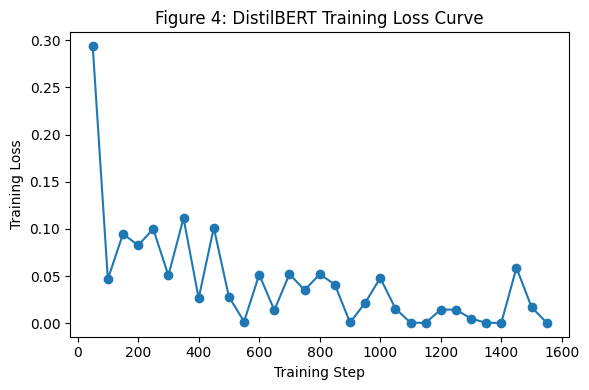


DistilBERT Results Table:
                   Model  Accuracy  Precision    Recall  F1-Score
0  Fine-tuned DistilBERT  0.991296   0.984127  0.946565  0.964981

DistilBERT training and evaluation completed successfully.


In [1]:
# ==========================================
# DISTILBERT MODEL FOR SMS SPAM CLASSIFICATION
# ==========================================

# Install required libraries
!pip install -q transformers datasets evaluate accelerate

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ==========================================
# LOAD DATASET
# ==========================================

DATA_PATH = Path("../data/SMSSpamCollection.csv") if Path("../data/SMSSpamCollection.csv").exists() else Path("data/SMSSpamCollection.csv")
df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Rename columns if Kaggle format is v1 and v2
if "v1" in df.columns and "v2" in df.columns:
    df = df.rename(columns={"v1": "label", "v2": "message"})

# Keep only required columns
df = df[["label", "message"]]

# Clean data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Convert labels
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df = df.dropna(subset=["label_num"])
df["label_num"] = df["label_num"].astype(int)

print("Dataset Shape:", df.shape)
print(df["label"].value_counts())

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# ==========================================
# TOKENIZATION
# ==========================================

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

# ==========================================
# LOAD PRETRAINED DISTILBERT MODEL
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# ==========================================
# METRICS FUNCTION
# ==========================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ==========================================
# TRAINING ARGUMENTS
# ==========================================

training_args = TrainingArguments(
    output_dir="./distilbert_spam_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    report_to="none"
)

# ==========================================
# TRAINER
# ==========================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# ==========================================
# TRAIN MODEL
# ==========================================

train_output = trainer.train()

# ==========================================
# EVALUATE MODEL
# ==========================================

eval_results = trainer.evaluate()

print("\n==============================")
print("DISTILBERT MODEL PERFORMANCE")
print("==============================")

for key, value in eval_results.items():
    print(key, ":", value)

# ==========================================
# PREDICTIONS
# ==========================================

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["ham", "spam"]))

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()

plt.title("Figure 3: Confusion Matrix for Fine-tuned DistilBERT")
plt.tight_layout()
OUTPUT_FIGURES_DIR = Path("../outputs/figures") if Path("../outputs").exists() else Path("outputs/figures")
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FIGURES_DIR / "figure3_distilbert_confusion_matrix.png", dpi=300)
plt.show()

# ==========================================
# TRAINING LOSS CURVE
# ==========================================

logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

plt.figure(figsize=(6,4))
plt.plot(steps, train_loss, marker="o")
plt.title("Figure 4: DistilBERT Training Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "figure4_distilbert_training_loss.png", dpi=300)
plt.show()

# ==========================================
# SAVE FINAL RESULTS TABLE
# ==========================================

distilbert_accuracy = accuracy_score(y_true, y_pred)
distilbert_precision = precision_score(y_true, y_pred)
distilbert_recall = recall_score(y_true, y_pred)
distilbert_f1 = f1_score(y_true, y_pred)

distilbert_results = pd.DataFrame({
    "Model": ["Fine-tuned DistilBERT"],
    "Accuracy": [distilbert_accuracy],
    "Precision": [distilbert_precision],
    "Recall": [distilbert_recall],
    "F1-Score": [distilbert_f1]
})

print("\nDistilBERT Results Table:")
print(distilbert_results)

OUTPUT_METRICS_DIR = Path("../outputs/metrics") if Path("../outputs").exists() else Path("outputs/metrics")
OUTPUT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
distilbert_results.to_csv(OUTPUT_METRICS_DIR / "distilbert_results.csv", index=False)

print("\nDistilBERT training and evaluation completed successfully.")